- Celda 1: Importar librerías

- Importar pandas
- Importar numpy
- Importar datetime
- Importar matplotlib.pyplot

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

- Celda 2: Ejercicio 1.1 - Importar y limpiar

- Importa "restaurante.csv" en DataFrame pedidos
- Elimina filas con nulos en columna Propina
- Muestra cuántas filas se eliminaron
- Muestra primeras 5 filas y tipos de datos

In [2]:
pedidos = pd.read_csv("restaurante.csv")

pedidos.head()

,ID,Fecha_Pedido,Numero_Mesa,Total_Cuenta,Propina,Costo_Platos,Visitas_Anteriores,Metodo_Pago
0,1,15/03/2024,5,"85,50",12.0,45.0,3,Efectivo
1,2,22/03/2024,12,120.00,18.5,60.0,7,Tarjeta
2,3,10/04/2024,8,65.00,8.0,35.0,1,Transferencia
3,4,05/05/2024,15,"95,75",14.0,50.0,4,Tarjeta
4,5,18/06/2024,22,110.00,16.5,55.0,8,Efectivo


In [3]:
pedidos["Propina"].isnull().sum()

np.int64(1)

In [4]:
pedidos.isnull().sum()

ID                    0
Fecha_Pedido          0
Numero_Mesa           0
Total_Cuenta          1
Propina               1
Costo_Platos          0
Visitas_Anteriores    0
Metodo_Pago           0
dtype: int64

In [5]:
# Para calcular cuantas filas se eliminan, primero calculamos cuantas antes de, y despues lo pintamos.
filas_antes = len(pedidos)

In [6]:
pedidos = pedidos.dropna() # Eliminar nulos de todo el dataframe
pedidos = pedidos.dropna(subset=['Propina']) # Eliminar nulos de una columna en concreto

In [7]:
# Aqui pintamos cuantas filas se eliminan despues de ejecutarlo el dropna
filas_eliminadas = filas_antes - len(pedidos)
print(f"Filas eliminadas: {filas_eliminadas}")
print(f"Filas restantes: {len(pedidos)}")

Filas eliminadas: 1
Filas restantes: 14


In [8]:
pedidos.head(5)

,ID,Fecha_Pedido,Numero_Mesa,Total_Cuenta,Propina,Costo_Platos,Visitas_Anteriores,Metodo_Pago
0,1,15/03/2024,5,"85,50",12.0,45.0,3,Efectivo
1,2,22/03/2024,12,120.00,18.5,60.0,7,Tarjeta
2,3,10/04/2024,8,65.00,8.0,35.0,1,Transferencia
3,4,05/05/2024,15,"95,75",14.0,50.0,4,Tarjeta
4,5,18/06/2024,22,110.00,16.5,55.0,8,Efectivo


In [9]:
# Ver el tipo de datos
print(pedidos.dtypes)


ID                      int64
Fecha_Pedido           object
Numero_Mesa             int64
Total_Cuenta           object
Propina               float64
Costo_Platos          float64
Visitas_Anteriores      int64
Metodo_Pago            object
dtype: object


- Celda 3: Ejercicio 1.2 - Convertir y filtrar

- Convierte Fecha_Pedido a Datetime
- Filtra pedidos entre 1-Marzo-2024 y 31-Agosto-2024 (cambio permanente)
- Crea columna Dia_Semana con el día de la semana
- Muestra cuántos pedidos hay por cada día

In [10]:
pedidos["Fecha_Pedido"] = pd.to_datetime(pedidos["Fecha_Pedido"],dayfirst=True, format="%d/%m/%Y")


In [11]:
pedidos.head()

,ID,Fecha_Pedido,Numero_Mesa,Total_Cuenta,Propina,Costo_Platos,Visitas_Anteriores,Metodo_Pago
0,1,2024-03-15,5,"85,50",12.0,45.0,3,Efectivo
1,2,2024-03-22,12,120.00,18.5,60.0,7,Tarjeta
2,3,2024-04-10,8,65.00,8.0,35.0,1,Transferencia
3,4,2024-05-05,15,"95,75",14.0,50.0,4,Tarjeta
4,5,2024-06-18,22,110.00,16.5,55.0,8,Efectivo


In [12]:
pedidos = pedidos[(pedidos["Fecha_Pedido"] >= "2024-03-01") & (pedidos["Fecha_Pedido"] <= "2024-08-31")]


In [13]:
pedidos.head(100)

,ID,Fecha_Pedido,Numero_Mesa,Total_Cuenta,Propina,Costo_Platos,Visitas_Anteriores,Metodo_Pago
0,1,2024-03-15,5,"85,50",12.0,45.0,3,Efectivo
1,2,2024-03-22,12,120.00,18.5,60.0,7,Tarjeta
2,3,2024-04-10,8,65.00,8.0,35.0,1,Transferencia
3,4,2024-05-05,15,"95,75",14.0,50.0,4,Tarjeta
4,5,2024-06-18,22,110.00,16.5,55.0,8,Efectivo
5,6,2024-07-25,3,45.00,5.0,25.0,0,Efectivo
6,7,2024-08-12,18,"135,00",20.0,70.0,10,Transferencia
13,14,2024-03-10,11,"92,00",13.0,49.0,2,Transferencia
14,15,2024-07-15,16,115.00,-5.0,62.0,7,Tarjeta


In [14]:
pedidos.shape

(9, 8)

In [15]:
pedidos["Dia_Semana"] = pedidos["Fecha_Pedido"].dt.dayofweek + 1 # + 1 para que empiece a partir del 1.

pedidos.head(15)


,ID,Fecha_Pedido,Numero_Mesa,Total_Cuenta,Propina,Costo_Platos,Visitas_Anteriores,Metodo_Pago,Dia_Semana
0,1,2024-03-15,5,"85,50",12.0,45.0,3,Efectivo,5
1,2,2024-03-22,12,120.00,18.5,60.0,7,Tarjeta,5
2,3,2024-04-10,8,65.00,8.0,35.0,1,Transferencia,3
3,4,2024-05-05,15,"95,75",14.0,50.0,4,Tarjeta,7
4,5,2024-06-18,22,110.00,16.5,55.0,8,Efectivo,2
5,6,2024-07-25,3,45.00,5.0,25.0,0,Efectivo,4
6,7,2024-08-12,18,"135,00",20.0,70.0,10,Transferencia,1
13,14,2024-03-10,11,"92,00",13.0,49.0,2,Transferencia,7
14,15,2024-07-15,16,115.00,-5.0,62.0,7,Tarjeta,1


In [16]:
pedidos["Dia_Semana"].unique()

array([5, 3, 7, 2, 4, 1], dtype=int32)

In [17]:
pedidos["Dia_Semana"].value_counts().sort_index()

Dia_Semana
1    2
2    1
3    1
4    1
5    2
7    2
Name: count, dtype: int64

- Celda 4: Ejercicio 1.3 - Columna Categoria_Cliente

- Recorre el DataFrame con for
- Crea columna "Categoria_Cliente":

- "VIP" si Total_Cuenta > 100 Y Propina > 15
- "Frecuente" si Visitas_Anteriores >= 5
- "Nuevo" en otros casos

- Muestra cuántos hay en cada categoría

In [18]:
pedidos["Total_Cuenta"] = pedidos["Total_Cuenta"].astype(str).str.replace(",", "").astype(float)
pedidos["Propina"] = pedidos["Propina"].astype(str).str.replace(",", "").astype(float)

In [19]:
Categoria_Cliente = []

for index, row in pedidos.iterrows():
    if (row["Total_Cuenta"] > 100) & (row["Propina"] > 15):
        Categoria_Cliente.append("VIP") 
    elif row["Visitas_Anteriores"] >= 5:
        Categoria_Cliente.append("Frecuente")
    else:
        Categoria_Cliente.append("Nuevo")

pedidos["Categoria_Cliente"] = Categoria_Cliente

pedidos.head()

,ID,Fecha_Pedido,Numero_Mesa,Total_Cuenta,Propina,Costo_Platos,Visitas_Anteriores,Metodo_Pago,Dia_Semana,Categoria_Cliente
0,1,2024-03-15,5,8550.0,12.0,45.0,3,Efectivo,5,Nuevo
1,2,2024-03-22,12,120.0,18.5,60.0,7,Tarjeta,5,VIP
2,3,2024-04-10,8,65.0,8.0,35.0,1,Transferencia,3,Nuevo
3,4,2024-05-05,15,9575.0,14.0,50.0,4,Tarjeta,7,Nuevo
4,5,2024-06-18,22,110.0,16.5,55.0,8,Efectivo,2,VIP


- Celda 5: Ejercicio 1.4 - Función calcular_margen

- Crea función calcular_margen que reciba un DataFrame
- Devuelve Series: (Total_Cuenta - Costo_Platos) / Total_Cuenta * 100
- Crea columna Margen_Porcentaje con el resultado
- Muestra margen promedio y máximo

In [20]:
def calcular_margen(df):
    series = (df["Total_Cuenta"] - df["Costo_Platos"]) / df["Total_Cuenta"]*100
    df["Margen_Porcentaje"] = series.round(2)
    return df

calcular_margen(pedidos)


,ID,Fecha_Pedido,Numero_Mesa,Total_Cuenta,Propina,Costo_Platos,Visitas_Anteriores,Metodo_Pago,Dia_Semana,Categoria_Cliente,Margen_Porcentaje
0,1,2024-03-15,5,8550.0,12.0,45.0,3,Efectivo,5,Nuevo,99.47
1,2,2024-03-22,12,120.0,18.5,60.0,7,Tarjeta,5,VIP,50.00
2,3,2024-04-10,8,65.0,8.0,35.0,1,Transferencia,3,Nuevo,46.15
3,4,2024-05-05,15,9575.0,14.0,50.0,4,Tarjeta,7,Nuevo,99.48
4,5,2024-06-18,22,110.0,16.5,55.0,8,Efectivo,2,VIP,50.00
5,6,2024-07-25,3,45.0,5.0,25.0,0,Efectivo,4,Nuevo,44.44
6,7,2024-08-12,18,13500.0,20.0,70.0,10,Transferencia,1,VIP,99.48
13,14,2024-03-10,11,9200.0,13.0,49.0,2,Transferencia,7,Nuevo,99.47
14,15,2024-07-15,16,115.0,-5.0,62.0,7,Tarjeta,1,Frecuente,46.09


In [21]:
print(np.mean(pedidos["Margen_Porcentaje"]))
print(pedidos["Margen_Porcentaje"].max())

70.50888888888889
99.48


- Celda 6: Ejercicio 1.5 - Convertir Metodo_Pago

- Limpia espacios de Metodo_Pago con .str.strip()
- Muestra valores únicos antes de convertir
- Convierte a numérico: Efectivo=1, Tarjeta=2, Transferencia=3
- Verifica que no queden NaN
- Muestra valores únicos después

In [22]:
pedidos["Metodo_Pago"].unique()

array(['Efectivo', 'Tarjeta', 'Transferencia', ' Efectivo '], dtype=object)

In [23]:
pedidos["Metodo_Pago"] = pedidos["Metodo_Pago"].str.strip()

In [24]:
pedidos["Metodo_Pago"] = pedidos["Metodo_Pago"].replace({
    "Efectivo": 1,
    "Tarjeta": 2,
    "Transferencia": 3
}).astype(int)

pedidos.head()

/tmp/ipykernel_5551/3321805668.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pedidos["Metodo_Pago"] = pedidos["Metodo_Pago"].replace({


,ID,Fecha_Pedido,Numero_Mesa,Total_Cuenta,Propina,Costo_Platos,Visitas_Anteriores,Metodo_Pago,Dia_Semana,Categoria_Cliente,Margen_Porcentaje
0,1,2024-03-15,5,8550.0,12.0,45.0,3,1,5,Nuevo,99.47
1,2,2024-03-22,12,120.0,18.5,60.0,7,2,5,VIP,50.00
2,3,2024-04-10,8,65.0,8.0,35.0,1,3,3,Nuevo,46.15
3,4,2024-05-05,15,9575.0,14.0,50.0,4,2,7,Nuevo,99.48
4,5,2024-06-18,22,110.0,16.5,55.0,8,1,2,VIP,50.00


In [25]:
pedidos.isna().sum()

ID                    0
Fecha_Pedido          0
Numero_Mesa           0
Total_Cuenta          0
Propina               0
Costo_Platos          0
Visitas_Anteriores    0
Metodo_Pago           0
Dia_Semana            0
Categoria_Cliente     0
Margen_Porcentaje     0
dtype: int64

In [26]:
pedidos["Metodo_Pago"].unique()

array([1, 2, 3])

- Celda 7: Ejercicio 1.6 - DataFrame Mejores_Pedidos

- Limpia Total_Cuenta (quitar comas, convertir a float)
- Crea DataFrame Mejores_Pedidos con:

Total_Cuenta > 50 O Propina > 10
Y Categoria_Cliente sea "VIP" o "Frecuente"

- Muestra cantidad de pedidos
- Muestra suma total de Total_Cuenta

In [27]:
pedidos["Total_Cuenta"] = pedidos["Total_Cuenta"].astype(str).str.replace(",", "").astype(float)

In [28]:
mejores_pedidos = pedidos[(
    (pedidos["Total_Cuenta"] > 50) | (pedidos["Propina"] > 10)
    ) & pedidos["Categoria_Cliente"].isin(["VIP", "Frecuente"])]

In [29]:
mejores_pedidos.head()

,ID,Fecha_Pedido,Numero_Mesa,Total_Cuenta,Propina,Costo_Platos,Visitas_Anteriores,Metodo_Pago,Dia_Semana,Categoria_Cliente,Margen_Porcentaje
1,2,2024-03-22,12,120.0,18.5,60.0,7,2,5,VIP,50.00
4,5,2024-06-18,22,110.0,16.5,55.0,8,1,2,VIP,50.00
6,7,2024-08-12,18,13500.0,20.0,70.0,10,3,1,VIP,99.48
14,15,2024-07-15,16,115.0,-5.0,62.0,7,2,1,Frecuente,46.09


In [30]:
mejores_pedidos.value_counts()

ID  Fecha_Pedido  Numero_Mesa  Total_Cuenta  Propina  Costo_Platos  Visitas_Anteriores  Metodo_Pago  Dia_Semana  Categoria_Cliente  Margen_Porcentaje
2   2024-03-22    12           120.0          18.5    60.0          7                   2            5           VIP                50.00                1
5   2024-06-18    22           110.0          16.5    55.0          8                   1            2           VIP                50.00                1
7   2024-08-12    18           13500.0        20.0    70.0          10                  3            1           VIP                99.48                1
15  2024-07-15    16           115.0         -5.0     62.0          7                   2            1           Frecuente          46.09                1
Name: count, dtype: int64

- Celda 8: Ejercicio 2.1 - Importar

- Importa "empleados.csv" en DataFrame empresa
- Muestra .info()
- Muestra .describe()
- Muestra valores únicos de Departamento

In [31]:
empleados = pd.read_csv("empleados.csv")

empleados.head()

,ID,Nombre,Edad,Departamento,Salario,Años_Experiencia,Evaluacion_Desempeño,Bono_Anual
0,1,Ana López,28,Ventas,45000,4,Bueno,4500
1,2,Carlos Ruiz,35,IT,75000,8,Excelente,11250
2,3,María García,42,RRHH,55000,12,Bueno,5500
3,4,Juan Pérez,31,Ventas,48000,6,Excelente,7200
4,5,Laura Torres,26,Marketing,42000,3,Regular,2100


In [32]:
empleados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID                    15 non-null     int64 
 1   Nombre                15 non-null     object
 2   Edad                  15 non-null     int64 
 3   Departamento          15 non-null     object
 4   Salario               15 non-null     int64 
 5   Años_Experiencia      15 non-null     int64 
 6   Evaluacion_Desempeño  15 non-null     object
 7   Bono_Anual            15 non-null     int64 
dtypes: int64(5), object(3)
memory usage: 1.1+ KB


In [33]:
empleados.describe()

,ID,Edad,Salario,Años_Experiencia,Bono_Anual
count,15.000000,15.000000,15.000000,15.00000,15.000000
mean,8.000000,34.400000,58666.666667,8.20000,6760.000000
std,4.472136,6.231258,12754.084313,3.87667,3789.656977
min,1.000000,26.000000,42000.000000,3.00000,0.000000
25%,4.500000,29.500000,48500.000000,5.00000,4600.000000
50%,8.000000,33.000000,55000.000000,8.00000,5500.000000
75%,11.500000,39.000000,67500.000000,11.00000,10125.000000
max,15.000000,45.000000,82000.000000,15.00000,12000.000000


In [34]:
empleados["Departamento"].unique()

array(['Ventas', 'IT', 'RRHH', 'Marketing'], dtype=object)

- Celda 9: Ejercicio 2.2 - Filtrar empleados destacados

- Filtra empleados con:

Salario > 50000 Y Años_Experiencia > 5
O Evaluacion_Desempeño == "Excelente"

- Guarda en empleados_destacados
- Ordena por Salario descendente
- Muestra top 3

In [35]:
empleados_destacados = empleados[((empleados["Salario"] > 50000) & (empleados["Salario"] > 5) | (empleados["Evaluacion_Desempeño"] == "Excelente" ))].sort_values(by=["Salario"], ascending=False)

empleados_destacados.head(3)

,ID,Nombre,Edad,Departamento,Salario,Años_Experiencia,Evaluacion_Desempeño,Bono_Anual
5,6,Pedro Sanz,45,IT,82000,15,Excelente,12000
13,14,Fernando Mora,44,IT,78000,14,Excelente,11700
1,2,Carlos Ruiz,35,IT,75000,8,Excelente,11250


- Celda 10: Ejercicio 2.3 - Calcular bonos

- Crea columna Bono_Calculado:

"Excelente": Salario * 0.15
"Bueno": Salario * 0.10
"Regular": Salario * 0.05
"Malo": 0

- Compara con Bono_Anual
- Muestra nombres donde diferencia > 0.01

In [36]:
bono_calculado = []

for index, row in empleados.iterrows():
    if row["Evaluacion_Desempeño"] == "Excelente":
        bono_calculado.append(row["Salario"] * 0.15)
    elif row["Evaluacion_Desempeño"] == "Bueno":
        bono_calculado.append(row["Salario"] * 0.10)
    elif row["Evaluacion_Desempeño"] == "Regular":
        bono_calculado.append(row["Salario"] * 0.05)
    elif row["Evaluacion_Desempeño"] == "Malo":
        bono_calculado.append(0)
    else:
        bono_calculado.append(0) 


empleados["Bono_Calculado"] = bono_calculado    

empleados.head(30)

,ID,Nombre,Edad,Departamento,Salario,Años_Experiencia,Evaluacion_Desempeño,Bono_Anual,Bono_Calculado
0,1,Ana López,28,Ventas,45000,4,Bueno,4500,4500.0
1,2,Carlos Ruiz,35,IT,75000,8,Excelente,11250,11250.0
2,3,María García,42,RRHH,55000,12,Bueno,5500,5500.0
3,4,Juan Pérez,31,Ventas,48000,6,Excelente,7200,7200.0
4,5,Laura Torres,26,Marketing,42000,3,Regular,2100,2100.0
5,6,Pedro Sanz,45,IT,82000,15,Excelente,12000,12300.0
6,7,Sofía Martín,29,RRHH,47000,5,Bueno,4700,4700.0
7,8,Diego Romero,38,Ventas,65000,10,Excelente,9750,9750.0
8,9,Elena Navarro,33,Marketing,51000,7,Bueno,5100,5100.0
9,10,Miguel Díaz,27,IT,58000,4,Regular,2900,2900.0


In [37]:
empleados["Diferencia"] = abs(empleados["Bono_Anual"] - empleados["Bono_Calculado"])
empleados.head(15)

,ID,Nombre,Edad,Departamento,Salario,Años_Experiencia,Evaluacion_Desempeño,Bono_Anual,Bono_Calculado,Diferencia
0,1,Ana López,28,Ventas,45000,4,Bueno,4500,4500.0,0.0
1,2,Carlos Ruiz,35,IT,75000,8,Excelente,11250,11250.0,0.0
2,3,María García,42,RRHH,55000,12,Bueno,5500,5500.0,0.0
3,4,Juan Pérez,31,Ventas,48000,6,Excelente,7200,7200.0,0.0
4,5,Laura Torres,26,Marketing,42000,3,Regular,2100,2100.0,0.0
5,6,Pedro Sanz,45,IT,82000,15,Excelente,12000,12300.0,300.0
6,7,Sofía Martín,29,RRHH,47000,5,Bueno,4700,4700.0,0.0
7,8,Diego Romero,38,Ventas,65000,10,Excelente,9750,9750.0,0.0
8,9,Elena Navarro,33,Marketing,51000,7,Bueno,5100,5100.0,0.0
9,10,Miguel Díaz,27,IT,58000,4,Regular,2900,2900.0,0.0


In [38]:
empleados[empleados["Diferencia"] > 0.01]["Nombre"]

5    Pedro Sanz
Name: Nombre, dtype: object

Celda 11: Ejercicio 2.4 - Correlación y agrupación

- Elimina columnas: ID, Nombre, Departamento, Evaluacion_Desempeño
- Calcula correlación
- Muestra variable con mayor correlación con Salario (excluyendo Salario)
- Agrupa por Departamento y muestra salario promedio y experiencia promedio
- Ordena por salario promedio descendente

In [39]:
empleados = empleados.drop(columns=["ID", "Nombre", "Departamento", "Evaluacion_Desempeño"])

empleados.head()

,Edad,Salario,Años_Experiencia,Bono_Anual,Bono_Calculado,Diferencia
0,28,45000,4,4500,4500.0,0.0
1,35,75000,8,11250,11250.0,0.0
2,42,55000,12,5500,5500.0,0.0
3,31,48000,6,7200,7200.0,0.0
4,26,42000,3,2100,2100.0,0.0


In [40]:
empleados.corr(numeric_only=True).abs()["Salario"].sort_values(ascending=False)[1:]

Bono_Calculado      0.838610
Bono_Anual          0.834971
Edad                0.784623
Años_Experiencia    0.778668
Diferencia          0.506110
Name: Salario, dtype: float64

In [41]:
# Agrupar por separado.

empleados.groupby("Departamento")["Salario"].mean()

KeyError: 'Departamento'

In [ ]:
empleados.groupby("Departamento")["Años_Experiencia"].mean()

Departamento
IT           10.25
Marketing     5.00
RRHH          9.50
Ventas        7.25
Name: Años_Experiencia, dtype: float64

In [ ]:
# Agrupar con mean además
agrupado = empleados.groupby('Departamento').agg({
    'Salario': 'mean',
    'Años_Experiencia': 'mean'
}).round(2)

agrupado = agrupado.sort_values('Salario', ascending=False)

print(agrupado)

               Salario  Años_Experiencia
Departamento                            
IT            73250.00             10.25
Ventas        57000.00              7.25
RRHH          54250.00              9.50
Marketing     47333.33              5.00


- Celda 12: Ejercicio 3.1 - Limpiar propinas negativas

- Reemplaza valores negativos en Propina por promedio de positivas
Usa .loc[], no for
Muestra cuántos valores se corrigieron

In [ ]:
pedidos.head(15)

,ID,Fecha_Pedido,Numero_Mesa,Total_Cuenta,Propina,Costo_Platos,Visitas_Anteriores,Metodo_Pago,Dia_Semana,Categoria_Cliente,Margen_Porcentaje
0,1,2024-03-15,5,8550.0,12.0,45.0,3,1,5,Nuevo,99.47
1,2,2024-03-22,12,120.0,18.5,60.0,7,2,5,VIP,50.00
2,3,2024-04-10,8,65.0,8.0,35.0,1,3,3,Nuevo,46.15
3,4,2024-05-05,15,9575.0,14.0,50.0,4,2,7,Nuevo,99.48
4,5,2024-06-18,22,110.0,16.5,55.0,8,1,2,VIP,50.00
5,6,2024-07-25,3,45.0,5.0,25.0,0,1,4,Nuevo,44.44
6,7,2024-08-12,18,13500.0,20.0,70.0,10,3,1,VIP,99.48
13,14,2024-03-10,11,9200.0,13.0,49.0,2,3,7,Nuevo,99.47
14,15,2024-07-15,16,115.0,-5.0,62.0,7,2,1,Frecuente,46.09


In [ ]:
promedio_positivas = pedidos.loc[pedidos['Propina'] > 0, 'Propina'].mean().round(1)
print(promedio_positivas)


13.4


In [ ]:
pedidos.loc[pedidos['Propina'] < 0, 'Propina'] = promedio_positivas
pedidos['Propina'] = pedidos['Propina'].round(1) # Para lo que redondeamos arriba a un decimal, pase al dataframe correctamente.
pedidos.head(15)

,ID,Fecha_Pedido,Numero_Mesa,Total_Cuenta,Propina,Costo_Platos,Visitas_Anteriores,Metodo_Pago,Dia_Semana,Categoria_Cliente,Margen_Porcentaje
0,1,2024-03-15,5,8550.0,12.0,45.0,3,1,5,Nuevo,99.47
1,2,2024-03-22,12,120.0,18.5,60.0,7,2,5,VIP,50.00
2,3,2024-04-10,8,65.0,8.0,35.0,1,3,3,Nuevo,46.15
3,4,2024-05-05,15,9575.0,14.0,50.0,4,2,7,Nuevo,99.48
4,5,2024-06-18,22,110.0,16.5,55.0,8,1,2,VIP,50.00
5,6,2024-07-25,3,45.0,5.0,25.0,0,1,4,Nuevo,44.44
6,7,2024-08-12,18,13500.0,20.0,70.0,10,3,1,VIP,99.48
13,14,2024-03-10,11,9200.0,13.0,49.0,2,3,7,Nuevo,99.47
14,15,2024-07-15,16,115.0,13.4,62.0,7,2,1,Frecuente,46.09


In [ ]:
pedios_totales = print(len(pedidos["Propina"]))
pedidos_negativos = (pedidos['Propina'] << 0).sum() # Si aqui pongo .count, cuentra los true y false.
print(f"Se corrigieron:  {pedidos_negativos}")

9
Se corrigieron:  1


Celda 13: Ejercicio 3.2 - Columna Hora_Servicio

- Crea columna Hora_Servicio:

"Almuerzo" si Numero_Mesa entre 1-10
"Cena" si Numero_Mesa entre 11-20
"Terraza" si Numero_Mesa > 20


- Cuenta pedidos por tipo
Calcula Total_Cuenta promedio por tipo

In [ ]:
Hora_Servicio = []

for index, row in pedidos.iterrows():
    if 1 <= row["Numero_Mesa"] <= 10:
        Hora_Servicio.append("Almuerzo")
    elif 11 <= row["Numero_Mesa"] <= 20:
        Hora_Servicio.append("Cena")
    elif row["Numero_Mesa"] > 20:
        Hora_Servicio.append("Terraza")
    else:
        Hora_Servicio.append("Otros")

pedidos["Hora_Servicio"] = Hora_Servicio

pedidos.head()


,ID,Fecha_Pedido,Numero_Mesa,Total_Cuenta,Propina,Costo_Platos,Visitas_Anteriores,Metodo_Pago,Dia_Semana,Categoria_Cliente,Margen_Porcentaje,Hora_Servicio
0,1,2024-03-15,5,8550.0,12.0,45.0,3,1,5,Nuevo,99.47,Almuerzo
1,2,2024-03-22,12,120.0,18.5,60.0,7,2,5,VIP,50.00,Cena
2,3,2024-04-10,8,65.0,8.0,35.0,1,3,3,Nuevo,46.15,Almuerzo
3,4,2024-05-05,15,9575.0,14.0,50.0,4,2,7,Nuevo,99.48,Cena
4,5,2024-06-18,22,110.0,16.5,55.0,8,1,2,VIP,50.00,Terraza


In [ ]:
pedidos["Hora_Servicio"].value_counts()

Hora_Servicio
Cena        5
Almuerzo    3
Terraza     1
Name: count, dtype: int64

In [ ]:
#Agrupar por dos columnas y hacer promedio
print(pedidos.groupby("Hora_Servicio") ["Total_Cuenta"].mean())


Hora_Servicio
Almuerzo    2886.666667
Cena        6502.000000
Terraza      110.000000
Name: Total_Cuenta, dtype: float64


Celda 14: Ejercicio 3.3 - Gráfico

- Agrupa por Metodo_Pago
- Suma Total_Cuenta
- Crea gráfico de barras verde
- Título: "Ingresos por Método de Pago"

In [ ]:
pedidos_agrupados = pedidos.groupby("Metodo_Pago")["Total_Cuenta"].sum()

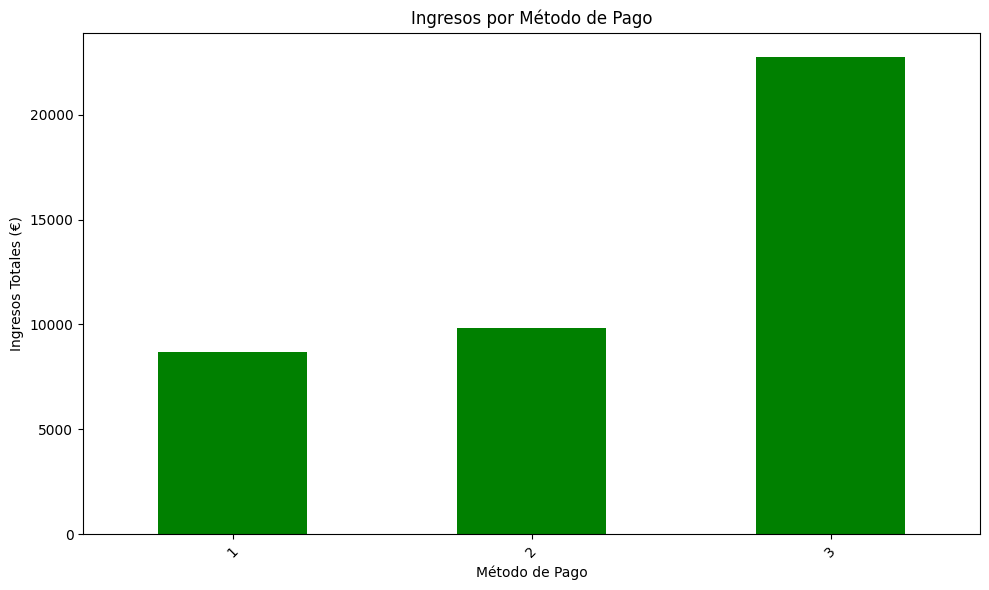

In [ ]:
import matplotlib.pyplot as plt


# Grafico de barras
plt.figure(figsize=(10, 6))
pedidos_agrupados.plot(kind='bar', color='green')
plt.title('Ingresos por Método de Pago')
plt.xlabel('Método de Pago')
plt.ylabel('Ingresos Totales (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()